<a href="https://colab.research.google.com/github/JosephNathaniel/ARENA/blob/main/chapter1_transformer_interp/exercises/part2_intro_to_mech_interp/induction-heads-rigorously.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Imports and setup

In [74]:
import einops
import math
import matplotlib.pyplot as plt
import numpy as np
import pdb # debugger
import random
import torch as t
import torch.nn as nn
import torch.nn.functional as F

In [75]:
DEVICE = "cuda" if t.cuda.is_available() else "cpu"

## Helper functions

In [76]:
# Function for generating repeated sequence dataset

def generate_repeated_tokens(
    vocab_size, seq_len: int, batch_size: int = 1, unique_tokens = False
) -> t.Tensor: # batch_size 2*seq_len
    """
    Generates a sequence of repeated random tokens

    Outputs are:
        rep_tokens: [batch_size, 1+2*seq_len]
    """
    if unique_tokens == True:
        # breakpoint()
        assert vocab_size >= seq_len, "If unique, vocab_size must be >= seq_len"
        rand_seqs = [random.sample(range(vocab_size), k=seq_len) for _ in range(batch_size)]
        rand_seqs = t.tensor(rand_seqs, device=DEVICE)
    else:
        rand_seqs = t.randint(low=0, high=vocab_size, size=(batch_size, seq_len)).to(DEVICE)

    return_tensor = t.concat([rand_seqs, rand_seqs], dim=1)
    return return_tensor

In [77]:
def logit_seq_plots(input: t.Tensor, title: str = None, x_label: str = None):
    if title is None:
        title = "Logit Sequence Plots"
    if x_label is None:
        x_label = "Sequence Position"
    plot_data = input.detach().numpy()
    n_components, seq_len = plot_data.shape
    x = range(seq_len)

    plt.figure(figsize=(8, 4))
    for i in range(n_components):
        plt.plot(x, plot_data[i], label=f'comp {i+1}')
    plt.xlabel(x_label)
    plt.ylabel('Logit Magnitude')
    plt.title(title)
    plt.legend(loc='upper right', ncol=2, fontsize='small')
    plt.tight_layout()
    plt.show()

In [78]:
def test_model_on_rep_tokens(model, test_seq_len: int, batch_size: int = 1024, unique_tokens: bool = False):
    """
    test_seq_len is the length of the random sequence. So the actual contexts will be double this
    """

    # generate test data
    test_sequences = generate_repeated_tokens(model.vocab_size, test_seq_len, batch_size, unique_tokens)

    # run model on test data
    with t.no_grad():
        output_logits = model(test_sequences, attention_mask=model.maximal_causal_mask) # batch 2*seq_len vocab

    # Get correct next-token indices
    target_ids = test_sequences[:, 1:]  # shape: (batch, 2*seq_len - 1)
    log_probs = t.log_softmax(output_logits, dim=-1)[:, :-1] # (batch, 2*seq_len-1, vocab_size)

    # Gather log probs for correct token
    correct_log_probs = log_probs.gather(dim=-1, index=target_ids.unsqueeze(-1)).squeeze(-1) # shape: (batch, 2*seq_len-1)

    # average across batch
    correct_log_probs_av = correct_log_probs.mean(dim=0)

    return correct_log_probs_av

In [79]:
def plot_correct_logprobs(correct_log_probs):
    # Plot
    plt.plot(correct_log_probs.cpu().numpy(), marker='o')
    plt.axvline(test_seq_len-1, color='red', linestyle='--', label='last token of initial sequence')
    plt.title("Log probs of correct next token")
    plt.xlabel("Token Position")
    plt.ylabel("Log Prob")
    plt.legend()
    plt.grid(True)
    plt.show()

# Part 1 -- a small, analytically constructed induction head

To verify my understanding the hypothesized induction head mechanism, I hand-crafted a relatively minimal set of weights that would implement this mechanism.
My construction involves a 2 layer transformer with 1 layer per head (i.e. these are precisely just the induction head and the previous-token head).
The main idea is to use a bunch of orthogonal vectors within the residual stream subspace, to juggle information around in independent subspaces so that they don't interfere with each other.

I implement this hand-crafted induction head model and verify that it behaves as expected on repeated sequences.

Note -- a lesson from the work below.
Softmax occurs in the attention mechanism as well as to decode the output logits.
One-hots that go through softmax are no longer 'peaky'. Hence, in the attention and output, we must use a big scaling factor, to get the desired peaky distribution after the softmax.

## Model

In [80]:
class AttentionBlock(nn.Module):
    """
    A single attention block according to the specified constraints:
    - 1 head
    - d_head = d_model
    - No MLP block
    - No LayerNorm
    - Positional embeddings added to Q and K inputs, not the residual stream.
    """
    def __init__(self, d_model: int, max_seq_len: int):
        super().__init__()
        self.d_model = d_model
        # Since num_heads = 1 and d_head = d_model, these are square matrices
        self.W_q = nn.Linear(d_model, d_model, bias=False)
        self.W_k = nn.Linear(d_model, d_model, bias=False)
        self.W_v = nn.Linear(d_model, d_model, bias=False)
        self.W_o = nn.Linear(d_model, d_model, bias=False)
        # Scale factor for attention
        self.scale = d_model ** -0.5


    def forward(self, x: t.Tensor, pos_emb: t.Tensor, mask: t.Tensor | None = None) -> t.Tensor:
        """
        Forward pass for the Attention Block.

        Args:
            x: Input tensor (residual stream). Shape: (batch_size, seq_len, d_model)
            pos_emb: Positional embeddings. Shape: (1, seq_len, d_model) or (batch_size, seq_len, d_model)
            mask: Optional attention mask. Shape: (batch_size, seq_len, seq_len) or similar broadcastable.
                  Positions with `False` or `0` will be masked out.

        Returns:
            Output tensor after attention and output projection. Shape: (batch_size, seq_len, d_model)
        """
        batch_size, seq_len, _ = x.shape

        # 1. Add positional embeddings *before* Q and K projections
        #    Value stream does not get positional embeddings.
        qk_input = x + pos_emb
        v_input = x # V uses the original residual stream state

        # 2. Project inputs to Q, K, V
        Q = self.W_q(qk_input) # Shape: (batch_size, seq_len, d_model)
        K = self.W_k(qk_input) # Shape: (batch_size, seq_len, d_model)
        V = self.W_v(v_input) # Shape: (batch_size, seq_len, d_model)

        # 3. Calculate scaled dot-product attention scores
        # (batch, seq_len, d_model) @ (batch, d_model, seq_len) -> (batch, seq_len, seq_len)
        attn_scores = einops.einsum(Q, K, "b sq d, b sk d -> b sq sk") * self.scale

        # 4. Apply attention mask (if provided)
        if mask is not None:
            if mask.dim() == 3:
                 mask = mask[:,:seq_len, :seq_len] # this will deal with overly-large causal mask
            else:
                 raise NotImplementedError

            # Masked positions (False) are filled with a large negative value
            attn_scores = attn_scores.masked_fill(mask == False, -1e9) # Use a large negative number

        # 5. Apply softmax to get attention probabilities
        attn_probs = F.softmax(attn_scores, dim=-1) # Shape: (batch_size, seq_len, seq_len)

        # 6. Calculate weighted sum of Values
        # (batch, seq_len, seq_len) @ (batch, seq_len, d_model) -> (batch, seq_len, d_model)
        attn_output = einops.einsum(attn_probs, V, "b sq sk, b sk d -> b sq d")

        # 7. Apply output projection
        output = self.W_o(attn_output) # Shape: (batch_size, seq_len, d_model)

        return output


class SimpleTransformer(nn.Module):
    """
    A simple 2-layer, attention-only Transformer with a specific positional embedding handling.
    """
    def __init__(self, vocab_size: int, d_model: int, num_layers: int, max_seq_len: int):
        super().__init__()
        assert num_layers == 2, "This specific implementation is hardcoded for num_layers=2"
        self.vocab_size = vocab_size
        self.d_model = d_model
        self.max_seq_len = max_seq_len

        # Token Embedding layer
        self.token_embedding = nn.Embedding(vocab_size, d_model)

        # Positional Embedding layer (will be added before Q and K, not to residual stream directly)
        self.positional_embedding = nn.Embedding(max_seq_len, d_model)

        # Stack of Attention Blocks
        self.layers = nn.ModuleList([AttentionBlock(d_model, max_seq_len) for _ in range(num_layers)])

        # Final linear layer to map back to vocabulary size (optional, for tasks like LM)
        self.unembed = nn.Linear(d_model, vocab_size, bias=False)

        # Create maximally sized causal mask. Shape (1, max_seq_len, max_seq_len)
        # False is masked, True is unmasked
        self.maximal_causal_mask = t.tril(t.ones(1,max_seq_len, max_seq_len)).bool()

    def forward(self, input_ids: t.Tensor, attention_mask: t.Tensor | None = None) -> t.Tensor:
        """
        Forward pass for the Simple Transformer.

        Args:
            input_ids: Input token IDs. Shape: (batch_size, seq_len)
            attention_mask: Optional mask to prevent attention to certain positions (e.g., padding).
                            Positions that are True are kept, False are masked.
                            Can handle overly large masks, various number of dimensions...
                            Will be converted to the appropriate shape for attention scores.

        Returns:
            Logits tensor. Shape: (batch_size, seq_len, vocab_size)
        """
        batch_size, seq_len = input_ids.shape
        if seq_len > self.max_seq_len:
             raise ValueError(f"Input sequence length ({seq_len}) exceeds model's max sequence length ({self.max_seq_len})")


        # 1. Get Token Embeddings
        token_emb = self.token_embedding(input_ids) # Shape: (batch_size, seq_len, d_model)

        # 2. Get Positional Embeddings
        # Create position IDs (0, 1, 2, ..., seq_len-1)
        position_ids = t.arange(0, seq_len, device=input_ids.device).unsqueeze(0) # Shape: (1, seq_len)
        pos_emb = self.positional_embedding(position_ids) # Shape: (1, seq_len, d_model)
        # pos_emb will broadcast correctly to (batch_size, seq_len, d_model) when added

        # Initial residual stream is just the token embeddings
        residual_stream = token_emb

        for layer in self.layers:
            # Pass the current residual stream and the *same* positional embeddings each time
            attn_output = layer(residual_stream, pos_emb, mask=attention_mask)
            # Add the output of the attention block back to the residual stream
            residual_stream = residual_stream + attn_output

        # 5. Final unembedding layer (optional)
        logits = self.unembed(residual_stream) # Shape: (batch_size, seq_len, vocab_size)

        return logits

## Example Usage

In [81]:
# Configuration
VOCAB_SIZE = 20
D_MODEL = 128
NUM_LAYERS = 2 # As requested
MAX_SEQ_LEN = 64
BATCH_SIZE = 4
DEVICE = "cuda" if t.cuda.is_available() else "cpu"

In [82]:
test_sequences = generate_repeated_tokens(VOCAB_SIZE, 20, BATCH_SIZE)
print(test_sequences)

tensor([[19, 14,  7, 10,  0, 11, 14,  6, 13,  1, 12,  7, 10, 19,  8, 15,  7,  2,
         15,  3, 19, 14,  7, 10,  0, 11, 14,  6, 13,  1, 12,  7, 10, 19,  8, 15,
          7,  2, 15,  3],
        [ 8, 17, 13,  4, 15, 17,  1,  8,  5, 14,  4,  4,  8,  7,  1,  3, 11,  7,
          6,  7,  8, 17, 13,  4, 15, 17,  1,  8,  5, 14,  4,  4,  8,  7,  1,  3,
         11,  7,  6,  7],
        [ 2, 10, 14, 15, 10,  8,  6,  0, 12, 10, 14,  2, 15, 18,  9,  8,  8, 13,
         13,  9,  2, 10, 14, 15, 10,  8,  6,  0, 12, 10, 14,  2, 15, 18,  9,  8,
          8, 13, 13,  9],
        [15, 18,  4,  5, 16, 11,  3,  2,  1, 12,  4, 18, 18,  7,  9,  6,  9,  1,
          2, 12, 15, 18,  4,  5, 16, 11,  3,  2,  1, 12,  4, 18, 18,  7,  9,  6,
          9,  1,  2, 12]])


In [83]:
# Instantiate the model
model = SimpleTransformer(
    vocab_size=VOCAB_SIZE,
    d_model=D_MODEL,
    num_layers=NUM_LAYERS,
    max_seq_len=MAX_SEQ_LEN
)
model.to(DEVICE)

print(f"Model:\n{model}")
num_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"\nTotal trainable parameters: {num_params:,}")

Model:
SimpleTransformer(
  (token_embedding): Embedding(20, 128)
  (positional_embedding): Embedding(64, 128)
  (layers): ModuleList(
    (0-1): 2 x AttentionBlock(
      (W_q): Linear(in_features=128, out_features=128, bias=False)
      (W_k): Linear(in_features=128, out_features=128, bias=False)
      (W_v): Linear(in_features=128, out_features=128, bias=False)
      (W_o): Linear(in_features=128, out_features=128, bias=False)
    )
  )
  (unembed): Linear(in_features=128, out_features=20, bias=False)
)

Total trainable parameters: 144,384


In [84]:
# Perform a forward pass
try:
    with t.no_grad(): # Disable gradient calculations for inference
        output_logits = model(test_sequences, attention_mask=model.maximal_causal_mask)

    print(f"\nInput shape: {test_sequences.shape}")
    print(f"Attention mask shape: {model.maximal_causal_mask.shape}")
    print(f"Output logits shape: {output_logits.shape}")
    print("\nForward pass successful!")

    # Verify masking (optional check)
    # Create a fully masked input and check if output changes significantly for masked parts
    masked_input = t.randint(0, VOCAB_SIZE, (1, MAX_SEQ_LEN))
    full_mask = t.zeros(1, MAX_SEQ_LEN, MAX_SEQ_LEN)
    out_fully_masked = model(masked_input, attention_mask=full_mask)
    out_no_mask = model(masked_input, attention_mask=t.ones(1,MAX_SEQ_LEN,MAX_SEQ_LEN))
    # This is a basic check; rigorous checks would involve inspecting attention scores.
    print(f"Output norm with no mask: {t.norm(out_no_mask)}")
    print(f"Output norm with full mask: {t.norm(out_fully_masked)} (should be similar if initial embedding dominates)")

except Exception as e:
    print(f"\nAn error occurred during forward pass: {e}")
    import traceback
    traceback.print_exc()


# Example with sequence length exceeding max_seq_len
print("\nTesting sequence length > max_seq_len:")
long_input_ids = t.randint(0, VOCAB_SIZE, (BATCH_SIZE, MAX_SEQ_LEN + 1))
try:
      with t.no_grad():
          output_logits = model(long_input_ids)
except ValueError as e:
      print(f"Caught expected error: {e}")


Input shape: torch.Size([4, 40])
Attention mask shape: torch.Size([1, 64, 64])
Output logits shape: torch.Size([4, 40, 20])

Forward pass successful!
Output norm with no mask: 21.090503692626953
Output norm with full mask: 21.099933624267578 (should be similar if initial embedding dominates)

Testing sequence length > max_seq_len:
Caught expected error: Input sequence length (65) exceeds model's max sequence length (64)


## Training

Let's play with it a bit to see that it's working as expected

In [85]:
# train on repeated sequences of length 20 (so, contexts of length 40)
train_sequences = generate_repeated_tokens(model.vocab_size, 20, 1024)

In [86]:
# Training hyperparameters
LEARNING_RATE = 1e-3
EPOCHS = 50
BATCH_SIZE = 32

In [87]:
# Loss function
loss_fn = nn.CrossEntropyLoss()

# Optimizer
optimizer = t.optim.Adam(model.parameters(), lr=LEARNING_RATE)

# Training loop
for epoch in range(EPOCHS):
    model.train()  # Set the model to training mode
    total_loss = 0

    for batch_idx in range(0, len(train_sequences), BATCH_SIZE):
        # Get a batch of data
        input_ids = train_sequences[batch_idx : batch_idx + BATCH_SIZE]
        targets = train_sequences[batch_idx : batch_idx + BATCH_SIZE, 1:]  # Shifted by one for next-token prediction

        # Zero the gradients
        optimizer.zero_grad()

        # Forward pass
        logits = model(input_ids, attention_mask=model.maximal_causal_mask)
        logits = logits[:, :-1]  # Remove last token from logits

        # Calculate the loss
        loss = loss_fn(logits.reshape(-1, logits.size(-1)), targets.reshape(-1))

        # Backward pass
        loss.backward()

        # Update the weights
        optimizer.step()

        total_loss += loss.item()

    avg_loss = total_loss / len(train_sequences)
    print(f"Epoch {epoch+1}/{EPOCHS}, Loss: {avg_loss:.4f}")

print("Training finished!")

Epoch 1/50, Loss: 0.0907
Epoch 2/50, Loss: 0.0536
Epoch 3/50, Loss: 0.0482
Epoch 4/50, Loss: 0.0471
Epoch 5/50, Loss: 0.0465
Epoch 6/50, Loss: 0.0462
Epoch 7/50, Loss: 0.0460
Epoch 8/50, Loss: 0.0458
Epoch 9/50, Loss: 0.0457
Epoch 10/50, Loss: 0.0455
Epoch 11/50, Loss: 0.0454
Epoch 12/50, Loss: 0.0453
Epoch 13/50, Loss: 0.0452
Epoch 14/50, Loss: 0.0452
Epoch 15/50, Loss: 0.0451
Epoch 16/50, Loss: 0.0450
Epoch 17/50, Loss: 0.0450
Epoch 18/50, Loss: 0.0449
Epoch 19/50, Loss: 0.0448
Epoch 20/50, Loss: 0.0447
Epoch 21/50, Loss: 0.0447
Epoch 22/50, Loss: 0.0446
Epoch 23/50, Loss: 0.0446
Epoch 24/50, Loss: 0.0446
Epoch 25/50, Loss: 0.0445
Epoch 26/50, Loss: 0.0445
Epoch 27/50, Loss: 0.0445
Epoch 28/50, Loss: 0.0444
Epoch 29/50, Loss: 0.0444
Epoch 30/50, Loss: 0.0443
Epoch 31/50, Loss: 0.0443
Epoch 32/50, Loss: 0.0442
Epoch 33/50, Loss: 0.0441
Epoch 34/50, Loss: 0.0441
Epoch 35/50, Loss: 0.0440
Epoch 36/50, Loss: 0.0440
Epoch 37/50, Loss: 0.0439
Epoch 38/50, Loss: 0.0439
Epoch 39/50, Loss: 0.

## Testing

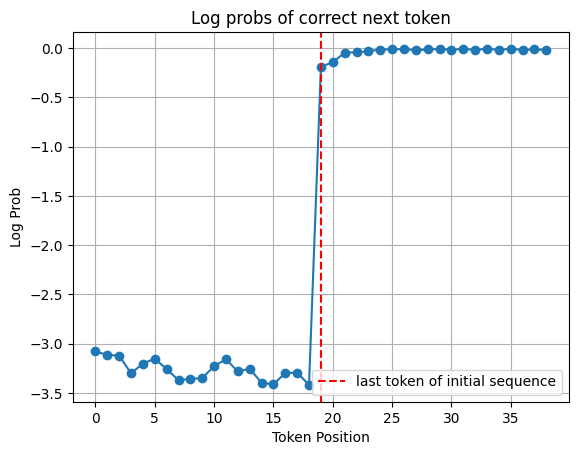

In [88]:
# let's see how well it generalizes to unseen length 20 sequences
test_seq_len = 20

correct_log_probs_av = test_model_on_rep_tokens(model, test_seq_len)

plot_correct_logprobs(correct_log_probs_av)

Nice, looks like it has learnt to do well on the second half of the sequence.

I.e., given a length `2*test_seq_len` repeated sequence, it is able to predict the second half of this correctly. So its predicted outputs on indices `test_seq_len-1` to `2*test_seq_len-2` are correct.

For fun, let's see if it has learned to generalize to different lengths of sequences

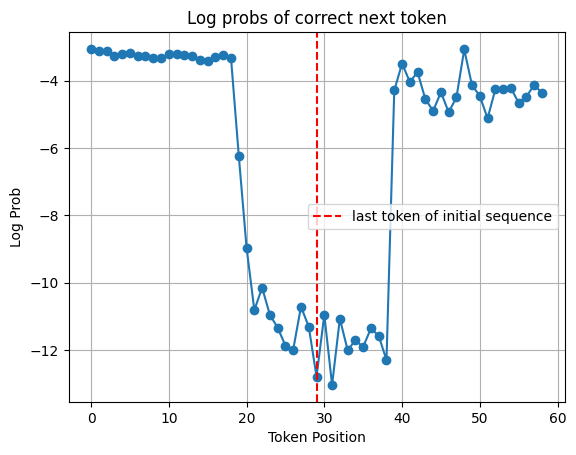

In [89]:
# look at how well it generalizes to unseen length-20 random sequences
test_seq_len = 30

correct_log_probs_av = test_model_on_rep_tokens(model, test_seq_len)

plot_correct_logprobs(correct_log_probs_av)

No, it has not generalized.
Explanation: the model was trained to repeat length 20 random sequences. So, after it sees the first 20, it tries to copy the initial sequence for tokens 20-40 ish, leading to the performance drop we see above

Then, apparently after the 40th token, it no longer knows what to do, so the error rate reverts to the baseline rate.

## Induction head transformer with manually set weights

In [90]:
manual_model = SimpleTransformer(
    vocab_size=VOCAB_SIZE,
    d_model=D_MODEL,
    num_layers=NUM_LAYERS,
    max_seq_len=MAX_SEQ_LEN
)
manual_model.to(DEVICE)


SimpleTransformer(
  (token_embedding): Embedding(20, 128)
  (positional_embedding): Embedding(64, 128)
  (layers): ModuleList(
    (0-1): 2 x AttentionBlock(
      (W_q): Linear(in_features=128, out_features=128, bias=False)
      (W_k): Linear(in_features=128, out_features=128, bias=False)
      (W_v): Linear(in_features=128, out_features=128, bias=False)
      (W_o): Linear(in_features=128, out_features=128, bias=False)
    )
  )
  (unembed): Linear(in_features=128, out_features=20, bias=False)
)

In [91]:
# we need a set of 3*VOCAB_SIZE + MAX_SEQ_LEN almost-orthogonal vectors
num_vectors = 3*VOCAB_SIZE + MAX_SEQ_LEN
print(num_vectors)

124


In [92]:
# for now we just take one-hots
one_hots = t.eye(D_MODEL, device=DEVICE)[:,:num_vectors]
print(one_hots.shape) # d_model, num_vectors. I.e., the vectors are the columns

# we can shuffle (the columns) for good measure
one_hots = one_hots[:,t.randperm(one_hots.shape[1])]

emb_vectors, unemb_vectors, prev_token_space, pos_encs = t.split(one_hots, [20, 20, 20, 64], dim=1)

torch.Size([128, 124])


Now, we use these to generate 2 sets of W_q, W_k, W_v, W_o weights, as per our induction head construction

For the initial layer head, the constraints are the following:

* Firstly,
$$W_{qk}=\mu\sum_{i=1}^\text{MAX_SEQ_LEN}|p_{i}\rangle \langle p_{i-1}|$$
where $p_i$ are the positional encoding vectors.
$\mu$ is some large scaling constant, to make the attention peaky even after softmax.
This means that in the attention mechanism, the query at position $i$ matches with the key at position $i-1$.

We can set $W_q$ to be the identity times the constant $\mu$, and get $W_k$ to do the shifting. So $W_k=|p_1\rangle\langle p_0|+|p_2\rangle\langle p_1|+\ldots +|p_\text{MAX_SEQ_LEN}\rangle\langle p_{\text{MAX_SEQ_LEN}-1}|$

* Secondly,
$$W_{ov}=\sum_{z=1}^\text{VOCAB_SIZE}|w_z\rangle\langle v_z|$$
where $v_z$ are the embedding vectors, and $w_z$ are the previous token space vectors.
This means it takes the token embedding $v_z$ to the previous-token-embedding $w_z$.

We can set $W_v$ to be the identity, and $W_o$ to be the matrix.

In [93]:
scale_factor = 1e6

In [94]:
# ======= W_q, head 0 =======
W_q0 = scale_factor * t.eye(D_MODEL, device=DEVICE)

# ======= W_k, head 0 =======
# do an outer product with einops. Need to be careful with indexing here
W_k0 = einops.einsum(pos_encs[:,1:], pos_encs[:,:-1], "dmod seq, dmod2 seq -> dmod dmod2")

# verify
assert (W_k0 @ pos_encs[:,:-1] == pos_encs[:,1:]).all()

# ======= W_v, head 0 =======
W_v0 = t.eye(D_MODEL, device=DEVICE)

# ======= W_o, head 0 =======
W_o0 = einops.einsum(prev_token_space, emb_vectors, "dmod vocab, dmod2 vocab -> dmod dmod2")

For the final layer head, the constraints are the following:

* Firstly,
$$W_{qk} = \mu\sum_{z=1}^\text{VOCAB_SIZE} |v_z\rangle\langle w_z|$$
This means that the current token $v_z$ looks for $w_z$, i.e. it looks for the stream following an earlier $z$ token.

We can set $W_q$ to be the identity times $\mu$ and get $W_k$ to do the matching work.

* Secondly,
$$W_{ov} = \mu \sum_{z=1}^\text{VOCAB_SIZE}|u_z\rangle\langle v_z|$$
where $u_z$ is the pre-embedding activation for predicing $z$ as the next token.
This means the stream with token $z$ yields a next token prediction of $z$, if paid attention to.
Because the outputs are logits which are softmaxed, this also needs to be scaled by a large factor.

We can set $W_v$ to be the identity times $\mu$ and get $W_o$ to do the work.

In [95]:
# ======= W_q, head 1 =======
W_q1 = scale_factor * t.eye(D_MODEL, device=DEVICE)

# ======= W_k, head 1 =======
W_k1 = einops.einsum(emb_vectors, prev_token_space, "dmod vocab, dmod2 vocab -> dmod dmod2")

# ======= W_v, head 1 =======
W_v1 = scale_factor * t.eye(D_MODEL, device=DEVICE)

# ======= W_o, head 1 =======
W_o1 = einops.einsum(unemb_vectors, emb_vectors, "dmod vocab, dmod2 vocab -> dmod dmod2")


In [96]:
# now, insert all the weights into the model
assert manual_model.token_embedding.weight.data.shape == emb_vectors.T.shape
assert manual_model.positional_embedding.weight.data.shape == pos_encs.T.shape
assert manual_model.layers[0].W_q.weight.data.shape == W_q0.shape
assert manual_model.layers[0].W_k.weight.data.shape == W_k0.shape
assert manual_model.layers[0].W_v.weight.data.shape == W_v0.shape
assert manual_model.layers[0].W_o.weight.data.shape == W_o0.shape
assert manual_model.layers[1].W_q.weight.data.shape == W_q1.shape
assert manual_model.layers[1].W_k.weight.data.shape == W_k1.shape
assert manual_model.layers[1].W_v.weight.data.shape == W_v1.shape
assert manual_model.layers[1].W_o.weight.data.shape == W_o1.shape
assert manual_model.unembed.weight.data.shape == unemb_vectors.T.shape

with t.no_grad():
  manual_model.token_embedding.weight.data = emb_vectors.T
  manual_model.positional_embedding.weight.data = pos_encs.T
  manual_model.layers[0].W_q.weight.data = W_q0
  manual_model.layers[0].W_k.weight.data = W_k0
  manual_model.layers[0].W_v.weight.data = W_v0
  manual_model.layers[0].W_o.weight.data = W_o0
  manual_model.layers[1].W_q.weight.data = W_q1
  manual_model.layers[1].W_k.weight.data = W_k1
  manual_model.layers[1].W_v.weight.data = W_v1
  manual_model.layers[1].W_o.weight.data = W_o1
  manual_model.unembed.weight.data = unemb_vectors.T

### Testing the manual model

Okay, now lets test our model on repeat sequences

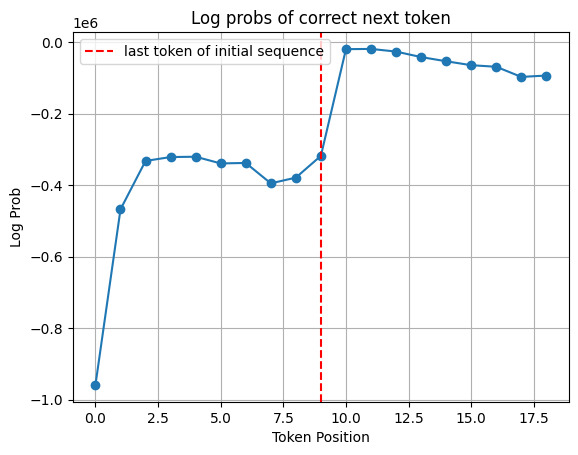

In [97]:
test_seq_len = 10

correct_log_probs_av = test_model_on_rep_tokens(manual_model, test_seq_len, batch_size=1024)

plot_correct_logprobs(correct_log_probs_av)

There's some of the expected behaviour going on, but it's far from perfect.

Side note: the prediction on the red dashed line is bad rather than good prediction. This is fine, and the reason is a little finicky. The correct predicted token on the red line is 0th token again. But since in this manual model, we have never seen the 0th token preceded by another token, we don't know to guess it. Whereas the previous models that were trained to repeated some fixed n-length sequence knows that at this point, the sequence will repeat, and hence guesses correctly.

Now, the random sequences we use for testing may contain repeats, which could confuse the heads. My manual induction head construction was not designed to deal with this.
Let's try generate random sequences without repeating tokens and test the manual model on that instead.

In [98]:
# e.g.
test_sequences[0]

tensor([19, 14,  7, 10,  0, 11, 14,  6, 13,  1, 12,  7, 10, 19,  8, 15,  7,  2,
        15,  3, 19, 14,  7, 10,  0, 11, 14,  6, 13,  1, 12,  7, 10, 19,  8, 15,
         7,  2, 15,  3])

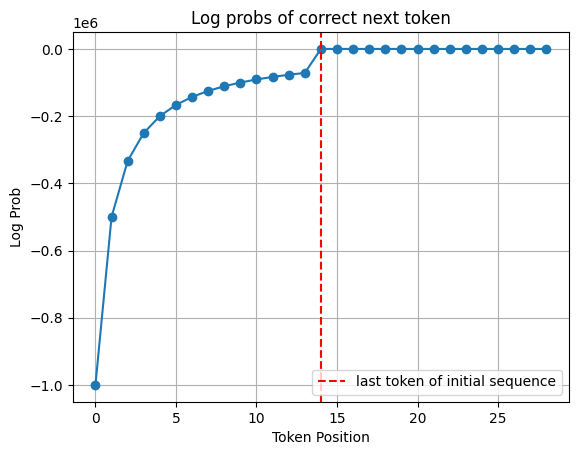

In [99]:
test_seq_len = 15

correct_log_probs_av = test_model_on_rep_tokens(manual_model, test_seq_len, unique_tokens=True, batch_size=1) # set unique_tokens = True

plot_correct_logprobs(correct_log_probs_av)

Nice, it is now perfect on the second half of the sequence

A technical note -- from the plot above it looks like it is absolutely perfect from token `test_seq_len-1` onwards, which would be inconsistent with what we expect from this manually constructed induction head.

But, noting that the y axis is scaled by a large value, we can see that in fact position `test_seq_len-1` and `test_seq_len` are not perfect, and it is only perfect from `test_seq_len+1` and onwards.

In [100]:
print(correct_log_probs_av[test_seq_len-2],
      correct_log_probs_av[test_seq_len-1],
      correct_log_probs_av[test_seq_len], # the last of the unique tokens. Our induction head is still at a loss for what to predict
      correct_log_probs_av[test_seq_len+1], # the input is back to initial token. Our induction head knows to look back, and predict the next token correctly
      correct_log_probs_av[test_seq_len+2],)

tensor(-71431.2188) tensor(-2.7081) tensor(-0.6931) tensor(0.) tensor(0.)


This is consistent with what we expect -- perfectly correct predictions at the *second* token of the second half of the sequence, i.e. at index `test_seq_len+1`.

### Conclusion

The bad behaviour on the first test, with repeated tokens, confused the model. The performance in the second half was better, but still imperfect and degraded with time. So, to make that robust, seems like some extra construction is needed.

# Part 2 -- a more rigorous reverse engineering of language model induction head

This follows the reverse engineering part of the ARENA notebook, but with more rigour. In particular, I make some arguments at each step for our right to ignore extraneous components, which was not done consistently in the ARENA notebook.

### More setup

In [101]:
import os
import sys
from pathlib import Path

import pkg_resources

IN_COLAB = "google.colab" in sys.modules

chapter = "chapter1_transformer_interp"
repo = "ARENA_3.0"
branch = "main"

# Install dependencies
installed_packages = [pkg.key for pkg in pkg_resources.working_set]
if "transformer-lens" not in installed_packages:
    %pip install transformer_lens==2.11.0 einops eindex-callum jaxtyping git+https://github.com/callummcdougall/CircuitsVis.git#subdirectory=python

# Get root directory, handling 3 different cases: (1) Colab, (2) notebook not in ARENA repo, (3) notebook in ARENA repo
root = (
    "/content"
    if IN_COLAB
    else "/root"
    if repo not in os.getcwd()
    else str(next(p for p in Path.cwd().parents if p.name == repo))
)

if Path(root).exists() and not Path(f"{root}/{chapter}").exists():
    if not IN_COLAB:
        !sudo apt-get install unzip
        %pip install jupyter ipython --upgrade

    if not os.path.exists(f"{root}/{chapter}"):
        !wget -P {root} https://github.com/callummcdougall/ARENA_3.0/archive/refs/heads/{branch}.zip
        !unzip {root}/{branch}.zip '{repo}-{branch}/{chapter}/exercises/*' -d {root}
        !mv {root}/{repo}-{branch}/{chapter} {root}/{chapter}
        !rm {root}/{branch}.zip
        !rmdir {root}/ARENA_3.0-{branch}


if f"{root}/{chapter}/exercises" not in sys.path:
    sys.path.append(f"{root}/{chapter}/exercises")

os.chdir(f"{root}/{chapter}/exercises")

In [102]:
from transformer_lens import (
    ActivationCache,
    FactoredMatrix,
    HookedTransformer,
    HookedTransformerConfig,
    utils,
)

from jaxtyping import Float, Int

from plotly_utils import hist, imshow, plot_comp_scores, plot_logit_attribution, plot_loss_difference


In [103]:
def decompose_layer_residual(cache: ActivationCache, layer: int) -> Float[t.Tensor, "n_heads+2 posn d_model"]:
    """
    Retrieves all the components in the residual stream after the specified layer,
    concatenating them along the 0th dim.
    Note -- we want the cache tensors to include the batch dimension

    The [i, :, :]th element is y_i (from notation above). The sum of these tensors along the 0th dim should
    be the input to the first attention layer.
    """
    y0 = cache["embed"].unsqueeze(0)  # shape (1, batch, seq, d_model)
    y1 = cache["pos_embed"].unsqueeze(0)  # shape (1, batch, seq, d_model)
    y_rest = einops.rearrange(cache["result", layer], "batch seq heads d_model -> heads batch seq d_model") # the output activations of the heads at layer

    # we put the pos embeds first, then the embs, then the head outputs
    return t.concat([y1, y0, y_rest], dim=0) # shape: heads+2 batch seq d_model

### Load model

In [104]:
cfg = HookedTransformerConfig(
    d_model=768,
    d_head=64,
    n_heads=12,
    n_layers=2,
    n_ctx=2048,
    d_vocab=50278,
    attention_dir="causal",
    attn_only=True,  # defaults to False
    tokenizer_name="EleutherAI/gpt-neox-20b",
    seed=398,
    use_attn_result=True,
    normalization_type=None,  # defaults to "LN", i.e. layernorm with weights & biases
    positional_embedding_type="shortformer",
)

In [105]:
from huggingface_hub import hf_hub_download

REPO_ID = "callummcdougall/attn_only_2L_half"
FILENAME = "attn_only_2L_half.pth"

weights_path = hf_hub_download(repo_id=REPO_ID, filename=FILENAME)

In [106]:
loaded_model = HookedTransformer(cfg)
pretrained_weights = t.load(weights_path, map_location=DEVICE, weights_only=True)
loaded_model.load_state_dict(pretrained_weights)

<All keys matched successfully>

In [107]:
# inspect the model
loaded_model.cfg

HookedTransformerConfig:
{'NTK_by_parts_factor': 8.0,
 'NTK_by_parts_high_freq_factor': 4.0,
 'NTK_by_parts_low_freq_factor': 1.0,
 'act_fn': None,
 'attention_dir': 'causal',
 'attn_only': True,
 'attn_scale': 8.0,
 'attn_scores_soft_cap': -1.0,
 'attn_types': None,
 'checkpoint_index': None,
 'checkpoint_label_type': None,
 'checkpoint_value': None,
 'd_head': 64,
 'd_mlp': None,
 'd_model': 768,
 'd_vocab': 50278,
 'd_vocab_out': 50278,
 'decoder_start_token_id': None,
 'default_prepend_bos': True,
 'device': device(type='cpu'),
 'dtype': torch.float32,
 'eps': 1e-05,
 'experts_per_token': None,
 'final_rms': False,
 'from_checkpoint': False,
 'gated_mlp': False,
 'init_mode': 'gpt2',
 'init_weights': True,
 'initializer_range': 0.02886751345948129,
 'load_in_4bit': False,
 'model_name': 'custom',
 'n_ctx': 2048,
 'n_devices': 1,
 'n_heads': 12,
 'n_key_value_heads': None,
 'n_layers': 2,
 'n_params': 4718592,
 'normalization_type': None,
 'num_experts': None,
 'original_architectur

### Generate some activations from rep_tokens

In [108]:
rep_token_batch = generate_repeated_tokens(loaded_model.cfg.d_vocab, 50, batch_size = 1) # can adjust batch size here

rep_logits, rep_cache = loaded_model.run_with_cache(rep_token_batch)

print(rep_logits.shape) # batch_size, seq_len, d_vocab

torch.Size([1, 100, 50278])


In [109]:
rep_cache["result", 0].shape

torch.Size([1, 100, 12, 768])

## Final layer OV circuit

The V stream on a final layer head takes as its input $v_j$ -- the residual stream activation at position $j$ after one layer of attention.
Each $v_j$ is a sum of 13 contributions -- 12 initial layer heads and the token embedding.

We want to decompose the input into these 13 components and look at their effects on the final output logits

We want to consider the expression
$$v_j W^{1.4}_{OV} W_U$$
which is a vector of logits over the vocab.
Here
$$v_j=emb_j + v_{j,H0.1} + \ldots + v_{j,H0.12}$$

So we could consider
\begin{align*}
    emb_j W_{OV}W_U \\
    v_{j,H0.1} W_{OV}W_U \\
    \ldots \\
    v_{j,H0.12} W_{OV}W_U
\end{align*}
which are the partial contributions to the final logits along some sequence, (assuming this sequence pays attention to position $j$).

**Ideally, we want to argue something like: $emb_j W_{OV}W_U$ alone accounts for the resulting probability distribution from $v_j W_{OV}W_U$, and the contributions from the other 12 components are negligible.**

A preliminary, but not super rigorous thing we can do to compare these 13 logit contributions above, is to just compare their respective maximal entries.

Note, this comparison is 'blind' to output position. It only says something about the case where H1.4 does pay attention to stream $j$.


torch.Size([13, 1, 100, 768])


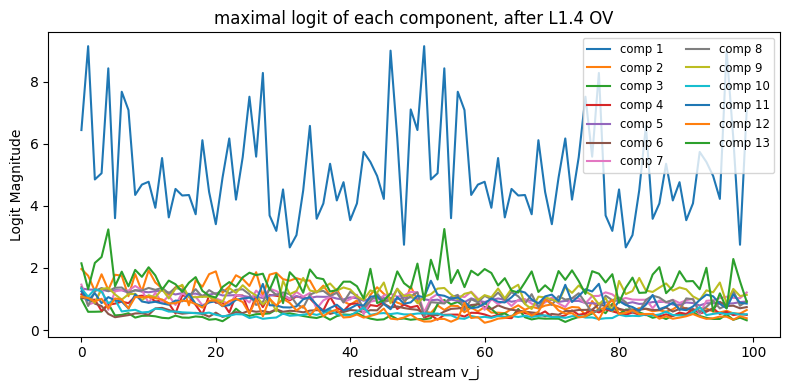

In [110]:
# get the 13 components of the intermediate residual stream
l1_ov_input = decompose_layer_residual(rep_cache, 0)[1:,:,:,:] # discard the pos_emb component
print(l1_ov_input.shape) # 13 batch seq d_mod

with t.no_grad():
  attributions = einops.einsum(l1_ov_input, loaded_model.W_V[1, 4], loaded_model.W_O[1,4], loaded_model.W_U,
                                       "comp batch seq d_mod, d_mod d_head, d_head d_mod2, d_mod2 vocab -> comp batch seq vocab")

  attributions = einops.reduce(attributions, "comp batch seq vocab -> comp seq vocab", "mean")
  max_attributions = einops.reduce(attributions, "comp seq vocab -> comp seq", "max")

  logit_seq_plots(max_attributions, title="maximal logit of each component, after L1.4 OV", x_label='residual stream v_j')

Now this is good, because we see that component 1 which corresponds to the token embeddings gives a maximum logit score that dominates that of all the other components (coming from the 12 first layer heads). Recall that a linear difference $\Delta$ between two logits maps via softmax onto a ratio of $\exp(\Delta)$ between the corresponding probabilities.
So a logit difference of 2 means a probability ratio of $\approx 7.4$.

However, the this is not rigorous evidence because softmax is sensitive only to 'relative differences' rather than absolute values.
In other words, a vector of logits is equivalent up to translation of all its components.
E.g., adding a vector of logits with large but equal values has no affect on the resulting probabilities.

Some stronger reasoning, though still far from unimpeachable, is the following:

Suppose we have a vector of logits $x$, such that $x = y + z$.
Recall that the 'content' of logits comes from the relative differences in its entries.
Thus, if the values in vector $z$ are tightly clustered with little variation, whereas the values in vector $y$ have relatively larger variation, then it seems reasonable to expect $y$ to account for most of the 'relative differences' in the logit $x$, such that in some sense "$x\approx y$ as logits".

So for instance, we can check that $std(y) \gg std(z)$.

In [111]:
fig = imshow(
    attributions.std(dim=-1),
    title="Std of H1.4 OV logit components, across the seq",
    labels={"x": "seq position", "y": "component"},
    width=1200,
    height=500,
)

This is good -- except for component 0, which has larger spread, all the other components have small spread.

Remark: there are probably other ways we could do this analysis even more rigorously, to support this idea that the logit contribution coming from H1.4's OV circuit is essentially just the one coming from the token embedding.


E.g. we might look at the contribution to the 'correct' logit, which would require us to match the input sequence $v_j$'s up with the output sequence position.
We could maybe run ablation based tests.

For fun, lets also check the embeddings give a 'peaky', approximately one-hot logit contribution

In [112]:
# take component 0 of attributions (corresponding to the embeddings)
topk_vals, topk_idx = attributions[0,:,:].topk(5, dim=-1)

print((topk_vals.T).shape) # k seq

torch.Size([5, 100])


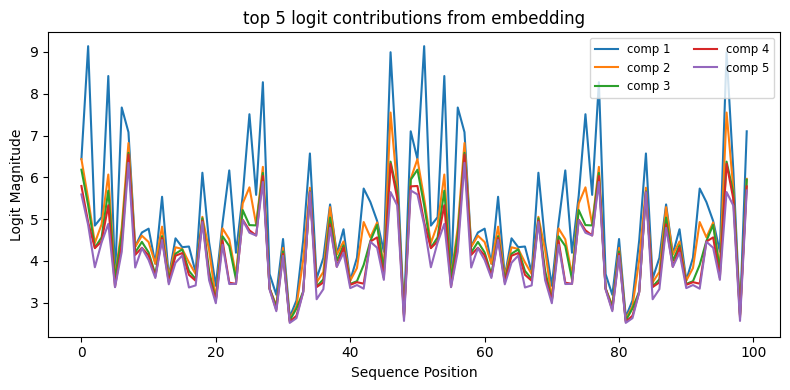

In [113]:
logit_seq_plots(topk_vals.T, 'top 5 logit contributions from embedding')

Hmm, this is less clear. It's not clear that it's cleanly one-hot. If we wanted to be more rigorous we could analyze this some more.
We could for instance visualize the softmax of this main logit contribution...

I think the noisiness in this plot (in terms of the dominance of the top logit over the other ones) relates to the previously observed fact that the $W_E W_{OV}^{1.4} W_U$ circuit is not perfectly diagonal, but quite noisy.

Now at this stage, if we accept it's the embeddings that are primarily being used by the H1.4 OV circuit, the question becomes what are the embeddings then predicting?

This is now where we rerun the previously done analysis for the L1 head OV circuit, by looking at
$$W_E W_{OV}^{1.4} W_U$$
and seeing that it is "roughly diagonal".

In [114]:
W_O = loaded_model.W_O[1, 4]
W_V = loaded_model.W_V[1, 4]
W_E = loaded_model.W_E
W_U = loaded_model.W_U

OV_circuit = FactoredMatrix(W_V, W_O)
full_OV_circuit = W_E @ OV_circuit @ W_U

# look at a random subset
indices = t.randint(0, loaded_model.cfg.d_vocab, (200,))
full_OV_circuit_sample = full_OV_circuit[indices, indices].AB

In [115]:
imshow(
    full_OV_circuit_sample,
    labels={"x": "Logits on output token", "y": "Input token"},
    title="Full OV circuit for copying head",
    width=700,
    height=600,
)

Then there was the stuff about computing circuit accuracy, noting that this was surprisingly low, and then redoing the analysis with the combined matrix $W_{OV}^{1.4}+W_{OV}^{1.10}$

## Initial layer QK circuit

For the initial layer H0.7 QK circuit, We want to think about
$$x_i W^Q (x_j W^K)^T$$
i.e. the attention score (pre softmax) that stream $i$ pays to stream $j$.
Here $x_i = pos_i + emb_i$.
To get the attention score (i.e. pre-softmax logits) at stream $i$, we aggregate this for all $j\leq i$.

Here the $x_i$, $x_j$ are the sum of their respective token embedding and positional embedding.
So overall this can be factored into a sum of $2\times 2=4$ pairwise contributions.

In [116]:
input_tensor = t.stack([rep_cache["pos_embed"], rep_cache["embed"]], dim=0) # 2 batch seq d_mod

In [117]:
print(loaded_model.W_Q[0,7].shape)
print(loaded_model.W_K[0,7].shape)

torch.Size([768, 64])
torch.Size([768, 64])


In [118]:
with t.no_grad():
    decompose_qk = einops.einsum(input_tensor, loaded_model.W_Q[0,7], loaded_model.W_K[0,7], input_tensor,
                  "compq batch seqq dmod, dmod dhead, dmod2 dhead, compk batch seqk dmod2 -> compq compk batch seqq seqk")
    decompose_qk = einops.reduce(decompose_qk, "compq compk batch seqq seqk-> compq compk seqq seqk", "mean") # mean over batches

In [119]:
# need to apply a causal mask
decompose_qk[0,0].shape

torch.Size([100, 100])

In [120]:
# apply causal mask
mask = t.triu(t.ones_like(decompose_qk[0,0]), diagonal=1).bool()
decompose_qk[:,:,mask] = -1e6

In [124]:
# plot the 4 attention score components
# Note that we apply softmax for better visualization of the logit contributions
imshow(
    # decompose_qk[0,0].tril(),
    F.softmax(decompose_qk[0,0],dim=-1),
    labels={"x": "key pos", "y": "query pos"},
    title="q=pos_emb, k=pos_emb",
    width=700,
    height=600,
)

imshow(
    # decompose_qk[0,1].tril(),
    F.softmax(decompose_qk[0,1],dim=-1),
    labels={"x": "key pos", "y": "query pos"},
    title="q=pos_emb, k=emb",
    width=700,
    height=600,
)

imshow(
    # decompose_qk[1,0].tril(),
    F.softmax(decompose_qk[1,0],dim=-1),
    labels={"x": "key pos", "y": "query pos"},
    title="q=emb, k=pos_emb",
    width=700,
    height=600,
)

imshow(
    # decompose_qk[1,1].tril(),
    F.softmax(decompose_qk[1,1],dim=-1),
    labels={"x": "key pos", "y": "query pos"},
    title="q=emb, k=emb",
    width=700,
    height=600,
)

Clearly, the (query = pos_emb, key = pos_emb) pair gives the off-by-one diagonal stripe we expect to see for the previous token head.

Now, we have to argue that it is precisely this component that is relevant for the logits, and the other 3 can be discarded.
Like before, this is a problem about discarding logit contributions. So we can again use the standard deviation as a rough proxy.

Now, getting the desired std is a little finicky, since we want to calculate the std of the rows of a matrix, but the matrix is lower triangular due to the mask.
So we probably shouldn't simply take the std along the row axis, because all the mask entries would affect this std!

In fact, I suspect this isn't dealt with properly in the ARENA notebook...

In [168]:
# prepare empty tensor
_, _, seq, _ = decompose_qk.shape
std_tensor = t.empty([2, 2, seq]) # compq compk seqq

# get lower-triangular indices (rows, cols) for all entries with j <= i
rows, cols = t.tril_indices(row=seq, col=seq, offset=0)

# for each row, select the entries (row, 0:row+1) and compute std
for row in range(seq):
    # indices for rows/cols
    idx = (rows == row).nonzero(as_tuple=False).squeeze(-1) # num_vals
    vals = decompose_qk[:,:,rows[idx], cols[idx]] # 2 2 num_vals
    # use unbiased=False so that std of a single element is zero, not NaN
    std_tensor[:,:,row] = vals.std(dim=-1, unbiased=False) # vals.std is (2,2)


In [169]:
# example
(rows==2).nonzero(as_tuple=False).squeeze(-1)

tensor([3, 4, 5])

In [170]:
imshow(
    einops.rearrange(std_tensor, "compq compk seqq -> (compq compk) seqq"),
    labels={"x": "query position", "y": "(q,k) pair"},
    title="attention score contribution stds",
    width=700,
    height=200,
)

# note we collapsed the first two axes into one
# this means:
# new index 0 --> original index (0,0) --> q=pos_emb, k=pos_emb
# new index 1 --> original index (0,1) --> q=pos_emb, k=emb
# new index 2 --> original index (1,0) --> q=emb, k=pos_emb
# new index 3 --> original index (1,1) --> q=emb, k=emb


We see that the 0'th component, corresponding to (query=pos_emb, key=pos_emb) has the largest std, and hence is the most important!

In more detail -- for every position in the input sequence, the attention pattern of H0.7 is primarily determined by (q=pos_emb, k=pos_emb).
The other contributions to the attention are probably negligible, since those logit contributions are tightly clustered.

In [183]:
# e.g.
query_index = 3
decompose_qk[0,0,query_index,:query_index+1]
decompose_qk[0,0,query_index,:query_index+1].std(unbiased=False)

tensor(43.8975)

## K-composition circuit

Finally we look at the composite of the OV circuit of the initial layer head and the QK circuit of the final layer head(s)